# Data Preprocessing

## Objective

The objective of this notebook is to prepare the manufacturing dataset for predictive modeling.

The preprocessing phase focuses on:

- Loading the validated manufacturing dataset
- Defining the prediction target
- Removing target leakage
- Preparing the feature matrix
- Splitting the data into training and testing datasets

The processed dataset will be used in subsequent notebooks for exploratory analysis and machine learning.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Load validated manufacturing dataset

df = pd.read_excel(r"D:\Projects\SQL\Manufacturing Process Optimization & Predictive Quality Analytics\Dataset\manufacturing_process_optimization.xlsx")

df.head()

,time_stamp,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Machine1.RawMaterial.Property3,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Machine1.Zone1Temperature.C.Actual,Machine1.Zone2Temperature.C.Actual,Machine1.MotorAmperage.U.Actual,Machine1.MotorRPM.C.Actual,Machine1.MaterialPressure.U.Actual,Machine1.MaterialTemperature.U.Actual,Machine1.ExitZoneTemperature.C.Actual,Machine2.RawMaterial.Property1,Machine2.RawMaterial.Property2,Machine2.RawMaterial.Property3,Machine2.RawMaterial.Property4,Machine2.RawMaterialFeederParameter.U.Actual,Machine2.Zone1Temperature.C.Actual,Machine2.Zone2Temperature.C.Actual,Machine2.MotorAmperage.U.Actual,Machine2.MotorRPM.C.Actual,Machine2.MaterialPressure.U.Actual,Machine2.MaterialTemperature.U.Actual,Machine2.ExitZoneTemperature.C.Actual,Machine3.RawMaterial.Property1,Machine3.RawMaterial.Property2,Machine3.RawMaterial.Property3,Machine3.RawMaterial.Property4,Machine3.RawMaterialFeederParameter.U.Actual,Machine3.Zone1Temperature.C.Actual,Machine3.Zone2Temperature.C.Actual,Machine3.MotorAmperage.U.Actual,Machine3.MotorRPM.C.Actual,Machine3.MaterialPressure.U.Actual,Machine3.MaterialTemperature.U.Actual,Machine3.ExitZoneTemperature.C.Actual,FirstStage.CombinerOperation.Temperature1.U.Actual,FirstStage.CombinerOperation.Temperature2.U.Actual,FirstStage.CombinerOperation.Temperature3.C.Actual,Stage1.Output.Measurement0.U.Actual,Stage1.Output.Measurement0.U.Setpoint,Stage1.Output.Measurement1.U.Actual,Stage1.Output.Measurement1.U.Setpoint,Stage1.Output.Measurement2.U.Actual,Stage1.Output.Measurement2.U.Setpoint,Stage1.Output.Measurement3.U.Actual,Stage1.Output.Measurement3.U.Setpoint,Stage1.Output.Measurement4.U.Actual,Stage1.Output.Measurement4.U.Setpoint,Stage1.Output.Measurement5.U.Actual,Stage1.Output.Measurement5.U.Setpoint,Stage1.Output.Measurement6.U.Actual,Stage1.Output.Measurement6.U.Setpoint,Stage1.Output.Measurement7.U.Actual,Stage1.Output.Measurement7.U.Setpoint,Stage1.Output.Measurement8.U.Actual,Stage1.Output.Measurement8.U.Setpoint,Stage1.Output.Measurement9.U.Actual,Stage1.Output.Measurement9.U.Setpoint,Stage1.Output.Measurement10.U.Actual,Stage1.Output.Measurement10.U.Setpoint,Stage1.Output.Measurement11.U.Actual,Stage1.Output.Measurement11.U.Setpoint,Stage1.Output.Measurement12.U.Actual,Stage1.Output.Measurement12.U.Setpoint,Stage1.Output.Measurement13.U.Actual,Stage1.Output.Measurement13.U.Setpoint,Stage1.Output.Measurement14.U.Actual,Stage1.Output.Measurement14.U.Setpoint,Machine4.Temperature1.C.Actual,Machine4.Temperature2.C.Actual,Machine4.Pressure.C.Actual,Machine4.Temperature3.C.Actual,Machine4.Temperature4.C.Actual,Machine4.Temperature5.C.Actual,Machine4.ExitTemperature.U.Actual,Machine5.Temperature1.C.Actual,Machine5.Temperature2.C.Actual,Machine5.Temperature3.C.Actual,Machine5.Temperature4.C.Actual,Machine5.Temperature5.C.Actual,Machine5.Temperature6.C.Actual,Machine5.ExitTemperature.U.Actual,Stage2.Output.Measurement0.U.Actual,Stage2.Output.Measurement0.U.Setpoint,Stage2.Output.Measurement1.U.Actual,Stage2.Output.Measurement1.U.Setpoint,Stage2.Output.Measurement2.U.Actual,Stage2.Output.Measurement2.U.Setpoint,Stage2.Output.Measurement3.U.Actual,Stage2.Output.Measurement3.U.Setpoint,Stage2.Output.Measurement4.U.Actual,Stage2.Output.Measurement4.U.Setpoint,Stage2.Output.Measurement5.U.Actual,Stage2.Output.Measurement5.U.Setpoint,Stage2.Output.Measurement6.U.Actual,Stage2.Output.Measurement6.U.Setpoint,Stage2.Output.Measurement7.U.Actual,Stage2.Output.Measurement7.U.Setpoint,Stage2.Output.Measurement8.U.Actual,Stage2.Output.Measurement8.U.Setpoint,Stage2.Output.Measurement9.U.Actual,Stage2.Output.Measurement9.U.Setpoint,Stage2.Output.Measurement10.U.Actual,Stage2.Output.Measurement10.U.Setpoint,Stage2.Output.Measurement11.U.Actual,Stage2.Output.Measurement11.U.Setpoint,Stage2.Output.Measurement12.U.Actual,Stage2.Output.Measurement12.U.Setp

In [3]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 14088
Columns : 116


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14088 entries, 0 to 14087
Columns: 116 entries, time_stamp to Stage2.Output.Measurement14.U.Setpoint
dtypes: datetime64[ns](1), float64(108), int64(7)
memory usage: 12.5 MB


In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
time_stamp,14088,2019-03-06 12:49:24.765758208,2019-03-06 10:52:00,2019-03-06 11:51:00,2019-03-06 12:49:00,2019-03-06 13:48:00,2019-03-06 14:47:00,NaN
AmbientConditions.AmbientHumidity.U.Actual,14088.0,15.330759,13.84,14.04,15.12,16.63,17.24,1.188993
AmbientConditions.AmbientTemperature.U.Actual,14088.0,23.843635,23.02,23.53,23.93,24.16,24.43,0.373535
Machine1.RawMaterial.Property1,14088.0,11.851256,11.54,11.54,11.54,12.22,12.9,0.510309
Machine1.RawMaterial.Property2,14088.0,205.67632,200.0,200.0,200.0,201.0,236.0,11.606324
...,...,...,...,...,...,...,...,...
Stage2.Output.Measurement12.U.Setpoint,14088.0,1.85,1.85,1.85,1.85,1.85,1.85,0.0
Stage2.Output.Measurement13.U.Actual,14088.0,3.535251,-0.0,3.45,3.51,3.76,8.0,0.476824
Stage2.Output.Measurement13.U.Setpoint,14088.0,2.89,2.89,2.89,2.89,2.89,2.89,0.0
Stage2.Output.Measurement14.U.Actual,14088.0,7.515574,-3.437021,7.72,7.87,8.08,14.26,2.082948


## Target Variable Selection

During SQL analysis, **Stage 2 Measurement 4** exhibited the highest average deviation from its target setpoint and was therefore identified as the Critical-to-Quality (CTQ) characteristic.

Instead of predicting every quality measurement available in the dataset, this project focuses on predicting the most critical quality characteristic from manufacturing process parameters.

Target Variable:

**Stage2.Output.Measurement4.U.Actual**

In [6]:
target = "Stage2.Output.Measurement4.U.Actual"

y = df[target]

print(y.head())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Stage2.Output.Measurement4.U.Actual, dtype: float64


In [7]:
y.tail()

14083    0.0
14084    0.0
14085    0.0
14086    0.0
14087    0.0
Name: Stage2.Output.Measurement4.U.Actual, dtype: float64

In [8]:
y.value_counts()

Stage2.Output.Measurement4.U.Actual
0.00     12754
29.95       45
29.93       41
29.97       36
29.96       26
         ...  
31.01        1
31.29        1
31.21        1
30.58        1
34.09        1
Name: count, Length: 367, dtype: int64

### Prediction Target Selection

SQL analysis identified **Stage 2 Measurement 4** as the most critical quality characteristic due to its highest average deviation from the target setpoint.

However, exploratory analysis performed during the Python phase revealed that nearly 90% of its observations contained zero values, making it unsuitable for robust regression modeling.

To ensure a reliable predictive model while preserving the business objective of quality prediction, **Stage 1 Measurement 1** was selected as the machine learning target because it represents the next most critical quality characteristic with a meaningful data distribution.

In [9]:
target = "Stage1.Output.Measurement1.U.Actual"

y = df[target]

print(y.head())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Stage1.Output.Measurement1.U.Actual, dtype: float64


In [10]:
y.value_counts()

Stage1.Output.Measurement1.U.Actual
0.000000e+00    5900
1.387000e+01     386
1.386000e+01     369
1.385000e+01     356
1.388000e+01     355
                ... 
1.382940e+01       1
1.382882e+01       1
1.381799e+01       1
1.392869e+01       1
8.170000e-44       1
Name: count, Length: 359, dtype: int64

# Target Suitability Assessment

## Objective

Before developing a predictive model, it is important to evaluate whether each potential quality measurement is suitable as a machine learning target.

This assessment compares all quality measurements based on:

- Percentage of zero observations
- Mean quality deviation from setpoint
- Standard deviation of quality deviation

The objective is to select a prediction target that is both business-critical and statistically suitable for modeling.

In [11]:
results = []

# Stage 1 Measurements
for i in range(15):

    actual = f"Stage1.Output.Measurement{i}.U.Actual"
    setpoint = f"Stage1.Output.Measurement{i}.U.Setpoint"

    zero_count = (df[actual] == 0).sum()
    zero_percent = round(100 * zero_count / len(df),2)
    avg_deviation = round(np.mean(np.abs(df[actual] - df[setpoint])),2)
    std_deviation = round(np.std(np.abs(df[actual] - df[setpoint])),2)
    results.append([ f"Stage1_M{i}",zero_count,zero_percent,avg_deviation,std_deviation])

# Stage 2 Measurements
for i in range(15):

    actual = f"Stage2.Output.Measurement{i}.U.Actual"
    setpoint = f"Stage2.Output.Measurement{i}.U.Setpoint"

    zero_count = (df[actual] == 0).sum()
    zero_percent = round(100 * zero_count / len(df),2)
    avg_deviation = round(np.mean(np.abs(df[actual] - df[setpoint])),2)
    std_deviation = round(np.std(np.abs(df[actual] - df[setpoint])),2)
    results.append([ f"Stage2_M{i}",zero_count,zero_percent,avg_deviation,std_deviation])

target_summary = pd.DataFrame(results,columns=["Measurement","Zero_Count","Zero_Percent","Average_Deviation","Std_Deviation"])

target_summary

,Measurement,Zero_Count,Zero_Percent,Average_Deviation,Std_Deviation
0,Stage1_M0,70,0.50,0.81,0.45
1,Stage1_M1,5900,41.88,14.60,6.95
2,Stage1_M2,85,0.60,1.67,0.65
3,Stage1_M3,135,0.96,0.47,1.62
4,Stage1_M4,174,1.24,1.43,2.97
5,Stage1_M5,13400,95.12,2.61,0.57
6,Stage1_M6,4703,33.38,2.92,1.07
7,Stage1_M7,8761,62.19,1.86,1.41
8,Stage1_M8,777,5.52,1.46,4.62
9,Stage1_M9,722,5.12,1.48,4.04


## Target Selection

The SQL phase identified the following quality measurements with the highest average deviation from their target setpoints:

1. Stage 2 Measurement 4
2. Stage 1 Measurement 1
3. Stage 1 Measurement 14
4. Stage 2 Measurement 1
5. Stage 2 Measurement 9

Further assessment showed that the top three measurements contained a high proportion of zero observations, reducing their suitability for predictive modeling.

Among the critical quality measurements, **Stage 2 Measurement 1** exhibited a comparatively low percentage of zero values (4.8%) while still representing one of the highest quality deviations.

Therefore, Stage 2 Measurement 1 was selected as the prediction target for subsequent machine learning analysis.

In [12]:
target_updated = "Stage2.Output.Measurement1.U.Actual"

y = df[target_updated]

In [13]:
X = df.drop(columns=[target_updated])

In [14]:
quality_columns = [col for col in X.columns if "Output.Measurement" in col]

X = X.drop(columns=quality_columns)

In [15]:
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

X.head()

Feature Matrix Shape : (14088, 56)
Target Shape : (14088,)


,time_stamp,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Machine1.RawMaterial.Property3,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Machine1.Zone1Temperature.C.Actual,Machine1.Zone2Temperature.C.Actual,Machine1.MotorAmperage.U.Actual,Machine1.MotorRPM.C.Actual,Machine1.MaterialPressure.U.Actual,Machine1.MaterialTemperature.U.Actual,Machine1.ExitZoneTemperature.C.Actual,Machine2.RawMaterial.Property1,Machine2.RawMaterial.Property2,Machine2.RawMaterial.Property3,Machine2.RawMaterial.Property4,Machine2.RawMaterialFeederParameter.U.Actual,Machine2.Zone1Temperature.C.Actual,Machine2.Zone2Temperature.C.Actual,Machine2.MotorAmperage.U.Actual,Machine2.MotorRPM.C.Actual,Machine2.MaterialPressure.U.Actual,Machine2.MaterialTemperature.U.Actual,Machine2.ExitZoneTemperature.C.Actual,Machine3.RawMaterial.Property1,Machine3.RawMaterial.Property2,Machine3.RawMaterial.Property3,Machine3.RawMaterial.Property4,Machine3.RawMaterialFeederParameter.U.Actual,Machine3.Zone1Temperature.C.Actual,Machine3.Zone2Temperature.C.Actual,Machine3.MotorAmperage.U.Actual,Machine3.MotorRPM.C.Actual,Machine3.MaterialPressure.U.Actual,Machine3.MaterialTemperature.U.Actual,Machine3.ExitZoneTemperature.C.Actual,FirstStage.CombinerOperation.Temperature1.U.Actual,FirstStage.CombinerOperation.Temperature2.U.Actual,FirstStage.CombinerOperation.Temperature3.C.Actual,Machine4.Temperature1.C.Actual,Machine4.Temperature2.C.Actual,Machine4.Pressure.C.Actual,Machine4.Temperature3.C.Actual,Machine4.Temperature4.C.Actual,Machine4.Temperature5.C.Actual,Machine4.ExitTemperature.U.Actual,Machine5.Temperature1.C.Actual,Machine5.Temperature2.C.Actual,Machine5.Temperature3.C.Actual,Machine5.Temperature4.C.Actual,Machine5.Temperature5.C.Actual,Machine5.Temperature6.C.Actual,Machine5.ExitTemperature.U.Actual
0,2019-03-06 10:52:00,17.24,23.53,11.54,200,963.0,247,1241.26,72.0,72.3,48.03,10.48,436.76,76.3,75.1,12.59,236,601.11,257,200.75,69.37,69.06,73.25,13.89,246.68,68.8,60.1,9.02,186,421.16,200,203.95,78.2,78.4,337.40,13.50,263.71,65.3,65.0,99.1,108.2,80.0,298.0,284.0,21.0,268.0,21.0,260.0,35.0,309.8,289.9,263.9,238.6,245.0,66.1,50.0
1,2019-03-06 10:52:00,17.24,23.53,11.54,200,963.0,247,1246.09,72.0,72.3,48.03,10.48,436.77,76.3,75.1,12.59,236,601.11,257,220.16,69.35,69.05,73.19,13.89,246.02,69.0,60.0,9.02,186,421.16,200,213.36,78.1,78.4,341.85,13.59,262.88,65.3,65.0,99.1,109.2,80.0,301.0,287.0,23.0,270.0,23.0,263.0,35.0,309.8,289.9,263.9,238.6,245.0,66.1,49.8
2,2019-03-06 10:52:00,17.24,23.53,11.54,200,963.0,247,1246.29,72.0,72.3,48.16,10.48,425.46,76.3,75.1,12.59,236,601.11,257,216.84,69.37,69.07,73.19,13.85,247.18,68.9,60.0,9.02,186,421.16,200,225.25,78.1,78.5,338.71,14.00,262.63,65.3,65.0,99.6,111.0,80.0,304.0,289.0,22.0,275.0,22.0,266.0,35.0,309.8,289.9,263.9,238.6,245.0,66.1,49.1
3,2019-03-06 10:52:00,17.24,23.53,11.54,200,963.0,247,1247.59,72.0,72.3,48.57,10.48,437.01,76.3,75.1,12.59,236,601.11,257,208.61,69.38,69.08,72.81,13.90,249.92,69.1,59.9,9.02,186,421.16,200,213.99,78.1,78.5,339.15,13.67,262.22,65.4,65.0,99.6,109.2,80.0,307.0,291.0,23.0,277.0,23.0,269.0,35.0,309.8,289.9,263.9,238.6,245.0,66.1,49.6
4,2019-03-06 10:52:00,17.24,23.53,11.54,200,963.0,247,1252.83,72.1,72.4,48.57,10.48,425.18,76.4,75.1,12.59,236,601.11,257,212.31,69.40,69.07,73.00,13.89,250.58,68.9,59.9,9.02,186,421.16,200,200.86,78.0,78.5,337.05,13.72,262.17,65.4,65.0,99.6,109.8,80.0,310.0,294.0,24.0,278.0,24.0,272.0,35.0,309.8,289.9,263.9,238.6,245.0,66.1,49.5


## Feature Selection

The objective of this project is to predict product quality using manufacturing process variables.

To avoid data leakage, all quality measurement columns (Stage 1 and Stage 2 output measurements) were removed from the feature matrix because these measurements would not be available at prediction time.

The final feature matrix therefore contains only process-related variables describing machine settings, raw material properties, environmental conditions, and process operating parameters.

In [16]:
# Check feature datatypes

X.dtypes.value_counts()

float64           49
int64              6
datetime64[ns]     1
Name: count, dtype: int64

In [17]:
# Check for non-numeric columns

X.select_dtypes(exclude='number').columns.tolist()

['time_stamp']

In [18]:
# Remove timestamp column

X = X.drop(columns=["time_stamp"])

In [19]:
X.dtypes.value_counts()

float64    49
int64       6
Name: count, dtype: int64

## Timestamp Handling

The dataset contains a timestamp column representing the production sequence.

Since this project focuses on predicting product quality from process parameters rather than time-series forecasting, the timestamp was removed from the feature matrix.

No meaningful temporal features (such as shift, day, or seasonality) were engineered because the production data represents a continuous manufacturing process.

# Exploratory Data Analysis (EDA)

## Objective

The objective of this section is to understand the statistical characteristics of both the selected target variable and the manufacturing process variables before model development.

The analysis focuses on:

- Distribution of the target variable
- Distribution of process variables
- Outlier detection
- Correlation analysis
- Relationship between process parameters and product quality

The findings from this section will guide feature engineering and model selection.

## Target Variable Distribution

Before training a regression model, it is important to understand the statistical distribution of the selected target variable.

This analysis helps identify:

- Central tendency
- Spread
- Skewness
- Presence of outliers
- Suitability for regression modeling

In [20]:
# Basic statistics of target variable

print("Mean   :", round(y.mean(), 2))
print("Median :", round(y.median(), 2))
print("Mode   :", y.mode()[0])

Mean   : 6.26
Median : 6.48
Mode   : 0.0


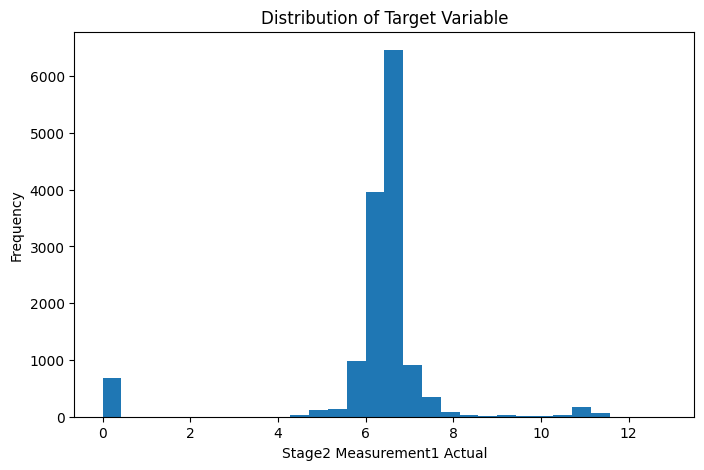

In [21]:
plt.figure(figsize=(8,5))
plt.hist(y, bins=30)
plt.title("Distribution of Target Variable")
plt.xlabel("Stage2 Measurement1 Actual")
plt.ylabel("Frequency")

plt.show()

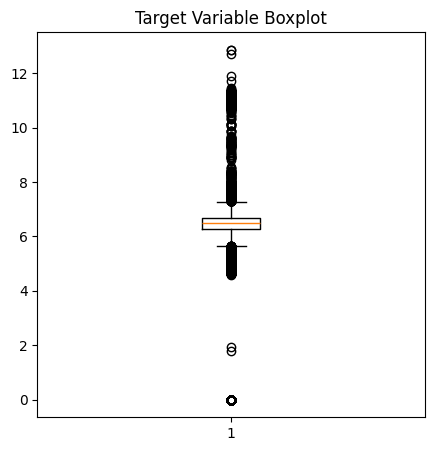

In [22]:
plt.figure(figsize=(5,5))
plt.boxplot(y)
plt.title("Target Variable Boxplot")
plt.show()

In [23]:
print("Skewness :", round(y.skew(),2))
print("Kurtosis :", round(y.kurt(),2))

Skewness : -2.29
Kurtosis : 9.77


### Business Insight

The selected target variable is concentrated around values between **6 and 7**, indicating that most products are manufactured within a relatively consistent quality range.

A small proportion of observations (approximately **4.8%**) contain zero values, which create a left-skewed distribution but are not dominant enough to invalidate the target for predictive modeling.

The target also exhibits several high-value outliers, suggesting occasional abnormal manufacturing behaviour that may provide valuable information for the machine learning model rather than simply representing noise.

## Process Variable Analysis

Objective

Understand the statistical behaviour of manufacturing process parameters before model development.

This analysis focuses on:

- Distribution of process variables
- Presence of skewness and outliers
- Overall data quality
- Identification of variables that may require transformation prior to model training

In [24]:
# Statistical summary of all process variables

process_summary = X.describe().T
process_summary

,count,mean,std,min,25%,50%,75%,max
AmbientConditions.AmbientHumidity.U.Actual,14088.0,15.330759,1.188993,13.840000,14.04,15.12,16.6300,17.240000
AmbientConditions.AmbientTemperature.U.Actual,14088.0,23.843635,0.373535,23.020000,23.53,23.93,24.1600,24.430000
Machine1.RawMaterial.Property1,14088.0,11.851256,0.510309,11.540000,11.54,11.54,12.2200,12.900000
Machine1.RawMaterial.Property2,14088.0,205.676320,11.606324,200.000000,200.00,200.00,201.0000,236.000000
Machine1.RawMaterial.Property3,14088.0,951.679815,126.662010,601.110000,963.00,963.00,1027.4300,1048.060000
Machine1.RawMaterial.Property4,14088.0,248.868896,3.297820,247.000000,247.00,247.00,251.0000,257.000000
Machine1.RawMaterialFeederParameter.U.Actual,14088.0,1242.764276,95.845946,231.300000,1257.17,1264.44,1273.4600,1331.820000
Machine1.Zone1Temperature.C.Actual,14088.0,72.013330,0.063183,71.900000,72.00,72.00,72.0000,72.500000
Machine1.Zone2Temperature.C.Actual,14088.0,72.013106,0.406313,71.300000,71.60,72.00,72.4000,72.700000
Machine1.MotorAmperage.U.Actual,14088.0,70.333111,5.525217,44.400000,68.88,71.98,72.9200,88.530000


In [25]:
process_summary["Range"] = process_summary["max"] - process_summary["min"]
process_summary["Coefficient_of_Variation"] = ( process_summary["std"] / process_summary["mean"])
process_summary = process_summary.round(2)
process_summary.head()

,count,mean,std,min,25%,50%,75%,max,Range,Coefficient_of_Variation
AmbientConditions.AmbientHumidity.U.Actual,14088.0,15.33,1.19,13.84,14.04,15.12,16.63,17.24,3.40,0.08
AmbientConditions.AmbientTemperature.U.Actual,14088.0,23.84,0.37,23.02,23.53,23.93,24.16,24.43,1.41,0.02
Machine1.RawMaterial.Property1,14088.0,11.85,0.51,11.54,11.54,11.54,12.22,12.90,1.36,0.04
Machine1.RawMaterial.Property2,14088.0,205.68,11.61,200.00,200.00,200.00,201.00,236.00,36.00,0.06
Machine1.RawMaterial.Property3,14088.0,951.68,126.66,601.11,963.00,963.00,1027.43,1048.06,446.95,0.13


In [26]:
process_summary.sort_values(by="Coefficient_of_Variation",ascending=False).head(15)

,count,mean,std,min,25%,50%,75%,max,Range,Coefficient_of_Variation
FirstStage.CombinerOperation.Temperature2.U.Actual,14088.0,84.90,18.58,53.30,69.00,74.80,104.20,115.20,61.90,0.22
Machine4.ExitTemperature.U.Actual,14088.0,187.14,23.65,35.00,191.00,192.00,193.00,216.00,181.00,0.13
Machine1.RawMaterial.Property3,14088.0,951.68,126.66,601.11,963.00,963.00,1027.43,1048.06,446.95,0.13
AmbientConditions.AmbientHumidity.U.Actual,14088.0,15.33,1.19,13.84,14.04,15.12,16.63,17.24,3.40,0.08
Machine1.MotorAmperage.U.Actual,14088.0,70.33,5.53,44.40,68.88,71.98,72.92,88.53,44.13,0.08
Machine3.RawMaterialFeederParameter.U.Actual,14088.0,202.38,15.65,0.00,193.98,202.91,211.79,259.07,259.07,0.08
Machine3.RawMaterial.Property2,14088.0,205.65,16.32,186.00,186.00,221.00,221.00,221.00,35.00,0.08
Machine1.RawMaterialFeederParameter.U.Actual,14088.0,1242.76,95.85,231.30,1257.17,1264.44,1273.46,1331.82,1100.52,0.08
Machine5.ExitTemperature.U.Actual,14088.0,153.98,10.31,45.40,154.20,155.60,156.60,159.20,113.80,0.07
Machine2.RawMaterialFeederParameter.U.Actual,14088.0,202.59,15.11,0.00,194.16,203.33,211.77,266.48,266.48,0.07


### Business Insight

The coefficient of variation highlights the manufacturing process parameters exhibiting the highest relative variability.

Parameters with higher variability may represent unstable operating conditions and are likely to require further investigation during correlation and feature importance analysis.

In [27]:
feature_skewness = (X.skew().sort_values(ascending=False).round(2))
feature_skewness

Machine2.Zone1Temperature.C.Actual                     7.35
Machine1.Zone1Temperature.C.Actual                     4.16
Machine2.Zone2Temperature.C.Actual                     3.25
Machine5.Temperature6.C.Actual                         2.11
Machine1.RawMaterial.Property2                         1.92
Machine1.RawMaterial.Property4                         1.60
Machine2.RawMaterial.Property3                         1.37
Machine2.RawMaterial.Property4                         1.37
Machine3.RawMaterial.Property1                         1.33
Machine2.MaterialPressure.U.Actual                     1.25
Machine1.RawMaterial.Property1                         1.16
Machine1.ExitZoneTemperature.C.Actual                  1.14
Machine3.MotorAmperage.U.Actual                        0.87
Machine4.Pressure.C.Actual                             0.78
Machine4.Temperature4.C.Actual                         0.78
Machine1.MotorRPM.C.Actual                             0.58
Machine3.Zone2Temperature.C.Actual      

In [28]:
highly_skewed = feature_skewness[abs(feature_skewness) > 1]
highly_skewed

Machine2.Zone1Temperature.C.Actual               7.35
Machine1.Zone1Temperature.C.Actual               4.16
Machine2.Zone2Temperature.C.Actual               3.25
Machine5.Temperature6.C.Actual                   2.11
Machine1.RawMaterial.Property2                   1.92
Machine1.RawMaterial.Property4                   1.60
Machine2.RawMaterial.Property3                   1.37
Machine2.RawMaterial.Property4                   1.37
Machine3.RawMaterial.Property1                   1.33
Machine2.MaterialPressure.U.Actual               1.25
Machine1.RawMaterial.Property1                   1.16
Machine1.ExitZoneTemperature.C.Actual            1.14
Machine1.MaterialPressure.U.Actual              -1.08
Machine2.RawMaterial.Property1                  -1.37
Machine2.RawMaterial.Property2                  -1.37
Machine4.Temperature1.C.Actual                  -1.48
Machine1.MotorAmperage.U.Actual                 -1.59
Machine2.RawMaterialFeederParameter.U.Actual    -1.83
Machine3.MaterialTemperature

### Business Insight

Several manufacturing process parameters exhibit skewed distributions, indicating that observations are concentrated within a limited operating range while a smaller number of observations extend into higher or lower values.

These variables will be reviewed during feature engineering to determine whether transformation is required before model training.

## Relationship Between Process Variables and Target

### Objective

The objective of this analysis is to identify the manufacturing process parameters that exhibit the strongest relationship with the selected quality measurement.

Understanding these relationships helps:

- Identify important predictive variables
- Validate findings obtained during SQL-based root cause analysis
- Support feature selection before model development

In [29]:
# Correlation of all features with target

feature_target_corr = X.corrwith(y)
feature_target_corr = (feature_target_corr.sort_values(key=abs, ascending=False).round(3))
feature_target_corr

Machine5.Temperature3.C.Actual                        0.576
Machine2.MaterialTemperature.U.Actual                 0.569
Machine4.ExitTemperature.U.Actual                     0.546
Machine5.Temperature6.C.Actual                       -0.482
Machine5.ExitTemperature.U.Actual                     0.433
Machine3.MaterialTemperature.U.Actual                 0.386
Machine1.Zone1Temperature.C.Actual                   -0.363
Machine1.MotorAmperage.U.Actual                       0.332
Machine2.MaterialPressure.U.Actual                   -0.328
Machine5.Temperature4.C.Actual                        0.311
Machine1.MaterialTemperature.U.Actual                 0.298
FirstStage.CombinerOperation.Temperature2.U.Actual   -0.272
Machine4.Temperature3.C.Actual                        0.266
Machine3.Zone1Temperature.C.Actual                   -0.245
Machine4.Temperature1.C.Actual                       -0.210
Machine3.ExitZoneTemperature.C.Actual                -0.189
Machine4.Temperature4.C.Actual          

In [30]:
feature_target_corr.head(15)

Machine5.Temperature3.C.Actual                        0.576
Machine2.MaterialTemperature.U.Actual                 0.569
Machine4.ExitTemperature.U.Actual                     0.546
Machine5.Temperature6.C.Actual                       -0.482
Machine5.ExitTemperature.U.Actual                     0.433
Machine3.MaterialTemperature.U.Actual                 0.386
Machine1.Zone1Temperature.C.Actual                   -0.363
Machine1.MotorAmperage.U.Actual                       0.332
Machine2.MaterialPressure.U.Actual                   -0.328
Machine5.Temperature4.C.Actual                        0.311
Machine1.MaterialTemperature.U.Actual                 0.298
FirstStage.CombinerOperation.Temperature2.U.Actual   -0.272
Machine4.Temperature3.C.Actual                        0.266
Machine3.Zone1Temperature.C.Actual                   -0.245
Machine4.Temperature1.C.Actual                       -0.210
dtype: float64

In [31]:
corr_df = feature_target_corr.reset_index()
corr_df.columns = ["Process_Parameter","Correlation_With_Target"]
corr_df.head(15)

,Process_Parameter,Correlation_With_Target
0,Machine5.Temperature3.C.Actual,0.576
1,Machine2.MaterialTemperature.U.Actual,0.569
2,Machine4.ExitTemperature.U.Actual,0.546
3,Machine5.Temperature6.C.Actual,-0.482
4,Machine5.ExitTemperature.U.Actual,0.433
5,Machine3.MaterialTemperature.U.Actual,0.386
6,Machine1.Zone1Temperature.C.Actual,-0.363
7,Machine1.MotorAmperage.U.Actual,0.332
8,Machine2.MaterialPressure.U.Actual,-0.328
9,Machine5.Temperature4.C.Actual,0.311


### Business Insight

The correlation analysis indicates that several temperature-related process parameters exhibit the strongest linear relationship with the selected quality measurement.

The highest positive correlations are observed for Machine 5 Temperature 3 (0.576), Machine 2 Material Temperature (0.569), and Machine 4 Exit Temperature (0.546), suggesting that increases in these parameters are associated with higher Stage 2 Measurement 1 values.

Conversely, Machine 5 Temperature 6 (-0.482), Machine 1 Zone 1 Temperature (-0.363), and Machine 2 Material Pressure (-0.328) demonstrate moderate negative correlations, indicating an inverse relationship with the target.

Interestingly, the variables identified through SQL-based Root Cause Analysis (such as Machine 1 Raw Material Property 3 and Motor Current) do not appear among the strongest linear predictors. This suggests that while they influence quality variation across operating ranges, their relationship with the target is likely non-linear and may be better captured by machine learning models rather than simple correlation analysis.

## Multicollinearity Analysis

### Objective

Manufacturing process parameters often measure similar physical behaviour.

This analysis investigates relationships between process variables to identify highly correlated features that may introduce redundancy into predictive models.

Understanding these relationships supports feature selection and improves model interpretability.

In [32]:
# Correlation matrix of process variables

corr_matrix = X.corr()
corr_matrix.head()

,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Machine1.RawMaterial.Property3,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Machine1.Zone1Temperature.C.Actual,Machine1.Zone2Temperature.C.Actual,Machine1.MotorAmperage.U.Actual,Machine1.MotorRPM.C.Actual,Machine1.MaterialPressure.U.Actual,Machine1.MaterialTemperature.U.Actual,Machine1.ExitZoneTemperature.C.Actual,Machine2.RawMaterial.Property1,Machine2.RawMaterial.Property2,Machine2.RawMaterial.Property3,Machine2.RawMaterial.Property4,Machine2.RawMaterialFeederParameter.U.Actual,Machine2.Zone1Temperature.C.Actual,Machine2.Zone2Temperature.C.Actual,Machine2.MotorAmperage.U.Actual,Machine2.MotorRPM.C.Actual,Machine2.MaterialPressure.U.Actual,Machine2.MaterialTemperature.U.Actual,Machine2.ExitZoneTemperature.C.Actual,Machine3.RawMaterial.Property1,Machine3.RawMaterial.Property2,Machine3.RawMaterial.Property3,Machine3.RawMaterial.Property4,Machine3.RawMaterialFeederParameter.U.Actual,Machine3.Zone1Temperature.C.Actual,Machine3.Zone2Temperature.C.Actual,Machine3.MotorAmperage.U.Actual,Machine3.MotorRPM.C.Actual,Machine3.MaterialPressure.U.Actual,Machine3.MaterialTemperature.U.Actual,Machine3.ExitZoneTemperature.C.Actual,FirstStage.CombinerOperation.Temperature1.U.Actual,FirstStage.CombinerOperation.Temperature2.U.Actual,FirstStage.CombinerOperation.Temperature3.C.Actual,Machine4.Temperature1.C.Actual,Machine4.Temperature2.C.Actual,Machine4.Pressure.C.Actual,Machine4.Temperature3.C.Actual,Machine4.Temperature4.C.Actual,Machine4.Temperature5.C.Actual,Machine4.ExitTemperature.U.Actual,Machine5.Temperature1.C.Actual,Machine5.Temperature2.C.Actual,Machine5.Temperature3.C.Actual,Machine5.Temperature4.C.Actual,Machine5.Temperature5.C.Actual,Machine5.Temperature6.C.Actual,Machine5.ExitTemperature.U.Actual
AmbientConditions.AmbientHumidity.U.Actual,1.000000,-0.197401,-0.634965,-0.530235,0.222924,-0.619726,0.083121,0.275358,0.021222,0.373958,-0.906481,0.564820,-0.649393,-0.530926,-0.649495,-0.649495,0.649495,0.649495,0.070240,-0.029439,0.062692,-0.653086,-0.009111,0.429913,-0.421316,0.007986,0.510488,-0.939665,-0.754554,-0.934318,0.075365,0.190348,0.071170,0.123688,0.821789,-0.349767,-0.667613,0.151922,-0.814300,-0.709565,-0.003349,0.086039,0.070218,-0.491183,-0.772584,-0.491183,-0.659076,-0.323570,-0.007235,0.006927,-0.447478,-0.748578,-0.049470,-0.106984,-0.229660
AmbientConditions.AmbientTemperature.U.Actual,-0.197401,1.000000,0.260897,0.190859,-0.208466,0.322569,-0.098109,0.012758,-0.007012,0.002999,0.442081,-0.215438,0.297221,0.523745,-0.106470,-0.106470,0.106470,0.106470,-0.033754,-0.023213,-0.029901,0.013501,0.001880,-0.063429,0.145710,-0.001233,-0.257414,0.025870,0.185660,-0.032329,-0.051020,-0.051630,-0.016248,-0.415579,-0.432849,-0.373122,-0.086899,-0.049168,0.477735,0.304831,0.007551,-0.045121,-0.035324,0.008720,0.011914,0.008720,-0.021319,0.136908,0.000818,0.010967,0.110663,0.407243,0.024275,0.276505,0.008383
Machine1.RawMaterial.Property1,-0.634965,0.260897,1.000000,0.791494,-0.488552,0.830277,-0.062169,-0.230600,-0.026998,-0.596093,0.657032,-0.822298,0.084999,0.086599,0.321770,0.321770,-0.321770,-0.321770,-0.024147,-0.041306,-0.015989,0.334776,0.011199,-0.213149,0.170134,-0.003453,-0.400625,0.573836,0.521012,0.549370,-0.043538,-0.073425,-0.026026,-0.175482,-0.435990,0.108056,0.317533,-0.014906,0.706109,0.627018,0.006959,-0.036012,-0.029738,0.305694,0.408061,0.305694,0.344068,0.121959,-0.006898,-0.009781,0.189414,0.384552,-0.008467,0.087740,0.085555
Machine1.RawMaterial.Property2,-0.530235,0.190859,0.791494,1.000000,-0.901975,0.935116,0.014332,-0.164382,-0.004444,-0.581848,0.632927,-0.867079,-0.036090,0.025919,0.258008,0.258008,-0.258008,-0.258008,-0.038612,-0.039354,-0.005397,0.227775,0.006007,-0.195851,0.133367,-0.000917,-0.321238,0.460125,0.417769,0.440507,-0.052152,-0.059673,-0.021434,-0.152560,-0.316658,0.072113,0.259263,0.001371,0.602083,0.50

In [33]:
corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().reset_index())
corr_pairs.columns = ["Feature_1","Feature_2","Correlation"]

corr_pairs["Absolute_Correlation"] = corr_pairs["Correlation"].abs()

corr_pairs = corr_pairs.sort_values(by="Absolute_Correlation",ascending=False)
corr_pairs.head(20)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
665,Machine2.RawMaterial.Property1,Machine2.RawMaterial.Property2,1.000000,1.000000
744,Machine2.RawMaterial.Property3,Machine2.RawMaterial.Property4,1.000000,1.000000
705,Machine2.RawMaterial.Property2,Machine2.RawMaterial.Property3,-1.000000,1.000000
1420,Machine4.Pressure.C.Actual,Machine4.Temperature4.C.Actual,1.000000,1.000000
667,Machine2.RawMaterial.Property1,Machine2.RawMaterial.Property4,-1.000000,1.000000
706,Machine2.RawMaterial.Property2,Machine2.RawMaterial.Property4,-1.000000,1.000000
666,Machine2.RawMaterial.Property1,Machine2.RawMaterial.Property3,-1.000000,1.000000
1108,Machine3.RawMaterial.Property2,Machine3.RawMaterial.Property4,0.981515,0.981515
1045,Machine2.MaterialTemperature.U.Actual,Machine5.Temperature3.C.Actual,0.945188,0.945188
26,AmbientConditions.AmbientHumidity.U.Actual,Machine3.RawMaterial.Property2,-0.939665,0.939665


# 9. Feature Engineering & Data Preparation

## Objective

Prepare the manufacturing dataset for machine learning by creating a clean feature matrix suitable for model development.

The preparation process includes:

- Train–test split
- Feature scaling
- Preserving an unbiased test dataset
- Building the final modeling dataset

In [34]:
from sklearn.model_selection import train_test_split

# Split features and target into training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [35]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (11270, 55)
Testing Features  : (2818, 55)

Training Target   : (11270,)
Testing Target    : (2818,)


### Business Insight

The dataset has been divided into training and testing subsets using an 80:20 ratio.

The training dataset will be used to develop predictive models, while the testing dataset will remain completely unseen during training to provide an unbiased evaluation of model performance.

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
print(X_train_scaled.shape)


(11270, 55)


In [38]:
print(X_test_scaled.shape)

(2818, 55)


In [39]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)

X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

In [40]:
X_train_scaled.describe().round(2)

,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Machine1.RawMaterial.Property3,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Machine1.Zone1Temperature.C.Actual,Machine1.Zone2Temperature.C.Actual,Machine1.MotorAmperage.U.Actual,Machine1.MotorRPM.C.Actual,Machine1.MaterialPressure.U.Actual,Machine1.MaterialTemperature.U.Actual,Machine1.ExitZoneTemperature.C.Actual,Machine2.RawMaterial.Property1,Machine2.RawMaterial.Property2,Machine2.RawMaterial.Property3,Machine2.RawMaterial.Property4,Machine2.RawMaterialFeederParameter.U.Actual,Machine2.Zone1Temperature.C.Actual,Machine2.Zone2Temperature.C.Actual,Machine2.MotorAmperage.U.Actual,Machine2.MotorRPM.C.Actual,Machine2.MaterialPressure.U.Actual,Machine2.MaterialTemperature.U.Actual,Machine2.ExitZoneTemperature.C.Actual,Machine3.RawMaterial.Property1,Machine3.RawMaterial.Property2,Machine3.RawMaterial.Property3,Machine3.RawMaterial.Property4,Machine3.RawMaterialFeederParameter.U.Actual,Machine3.Zone1Temperature.C.Actual,Machine3.Zone2Temperature.C.Actual,Machine3.MotorAmperage.U.Actual,Machine3.MotorRPM.C.Actual,Machine3.MaterialPressure.U.Actual,Machine3.MaterialTemperature.U.Actual,Machine3.ExitZoneTemperature.C.Actual,FirstStage.CombinerOperation.Temperature1.U.Actual,FirstStage.CombinerOperation.Temperature2.U.Actual,FirstStage.CombinerOperation.Temperature3.C.Actual,Machine4.Temperature1.C.Actual,Machine4.Temperature2.C.Actual,Machine4.Pressure.C.Actual,Machine4.Temperature3.C.Actual,Machine4.Temperature4.C.Actual,Machine4.Temperature5.C.Actual,Machine4.ExitTemperature.U.Actual,Machine5.Temperature1.C.Actual,Machine5.Temperature2.C.Actual,Machine5.Temperature3.C.Actual,Machine5.Temperature4.C.Actual,Machine5.Temperature5.C.Actual,Machine5.Temperature6.C.Actual,Machine5.ExitTemperature.U.Actual
count,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.0,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00,11270.00
mean,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.0,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.25,-2.21,-0.60,-0.48,-2.77,-0.56,-10.78,-1.82,-1.76,-4.68,-1.07,-2.44,-5.56,-3.03,-1.90,-1.90,-0.53,-0.53,-13.72,-5.65,-11.51,-4.64,-2.62,-2.33,-9.47,-2.49,-0.66,-1.20,-1.67,-1.4,-13.10,-9.67,-2.66,-2.62,-2.97,-1.90,-4.32,-3.33,-11.23,-1.70,-3.41,-26.99,-25.31,-3.43,-14.63,-3.43,-17.29,-6.49,-15.36,-5.77,-5.75,-3.19,-20.15,-1.55,-10.82
25%,-1.09,-0.84,-0.60,-0.48,0.09,-0.56,0.15,-0.21,-1.02,-0.12,-0.87,0.00,-0.51,-0.48,0.53,0.53,-0.53,-0.53,-0.57,-0.29,-0.29,-0.53,-0.91,-0.72,0.10,-0.63,-0.66,-1.20,-0.40,-1.4,-0.55,-0.11,-0.92,-0.68,-0.70,-0.65,-0.22,-0.14,-0.83,-0.85,-0.04,-0.05,-0.37,-0.25,-0.43,-0.25,-0.27,0.16,0.04,0.03,0.31,-0.48,0.05,-0.55,0.02
50%,-0.18,0.23,-0.60,-0.48,0.09,-0.56,0.22,-0.21,-0.04,0.29,-0.59,0.38,-0.19,-0.48,0.53,0.53,-0.53,-0.53,0.05,-0.12,-0.10,0.11,0.11,-0.02,0.22,-0.01,-0.66,0.94,0.86,0.9,0.03,-0.11,-0.05,-0.25,0.19,0.12,0.47,-0.14,-0.60,-0.54,-0.04,-0.05,-0.04,-0.25,0.37,-0.25,0.42,0.20,0.04,0.03,0.31,0.02,0.05,-0.06,0.16
75%,1.09,0.84,0.74,-0.40,0.60,0.65,0

### Business Insight

The process parameters were standardized using StandardScaler to ensure that all numerical features contribute equally during model training.

The scaler was fitted only on the training dataset to prevent information leakage from the testing dataset, ensuring an unbiased evaluation of predictive performance.

# 10. Baseline Model - Linear Regression

## Objective

Develop a baseline regression model to predict the selected quality measurement using the manufacturing process parameters.

Linear Regression provides a simple and interpretable benchmark against which more advanced machine learning models can be compared.

The model performance obtained in this section will serve as the reference for evaluating improvements achieved by tree-based ensemble models in later stages.

In [41]:
from sklearn.linear_model import LinearRegression

# Creating Linear Regression model
lr_model = LinearRegression()

# Training model

lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [42]:
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

In [43]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = mean_squared_error(y_train,y_train_pred) ** 0.5

train_r2 = r2_score(y_train,y_train_pred)

In [44]:
test_mae = mean_absolute_error(y_test,y_test_pred)

test_rmse = mean_squared_error(y_test,y_test_pred) ** 0.5

test_r2 = r2_score(y_test,y_test_pred)

In [45]:
print("Training Performance")
print(f"MAE  : {train_mae:.3f}")
print(f"RMSE : {train_rmse:.3f}")
print(f"R²   : {train_r2:.3f}")

print()

print("Testing Performance")
print(f"MAE  : {test_mae:.3f}")
print(f"RMSE : {test_rmse:.3f}")
print(f"R²   : {test_r2:.3f}")

Training Performance
MAE  : 0.553
RMSE : 1.157
R²   : 0.485

Testing Performance
MAE  : 0.561
RMSE : 1.172
R²   : 0.450


### Business Insight

The Linear Regression model establishes the baseline predictive performance for the selected quality measurement.

The model achieved similar performance on both the training (R² = 0.485) and testing (R² = 0.450) datasets, indicating that it generalizes well and does not exhibit significant overfitting.

However, the moderate R² values suggest that linear relationships alone are insufficient to explain the variation in manufacturing quality. This indicates the presence of more complex non-linear interactions between process parameters, motivating the use of tree-based ensemble models in subsequent stages of the project.

# 11. Random Forest Regression

## Objective

Develop a Random Forest Regression model to capture complex non-linear relationships between manufacturing process parameters and the selected quality measurement.

Unlike Linear Regression, Random Forest can model interactions between process variables without assuming a linear relationship, making it well suited for manufacturing process data.

In [46]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)
y_train_pred_rf = rf_model.predict(X_train)

y_test_pred_rf = rf_model.predict(X_test)

In [47]:
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_rmse_rf = mean_squared_error(y_train,y_train_pred_rf) ** 0.5
train_r2_rf = r2_score(y_train,y_train_pred_rf)

test_mae_rf = mean_absolute_error(y_test,y_test_pred_rf)
test_rmse_rf = mean_squared_error(y_test,y_test_pred_rf) ** 0.5
test_r2_rf = r2_score(y_test,y_test_pred_rf)

In [48]:
print("Training Performance")

print(f"MAE  : {train_mae_rf:.3f}")
print(f"RMSE : {train_rmse_rf:.3f}")
print(f"R²   : {train_r2_rf:.3f}")

print()

print("Testing Performance")

print(f"MAE  : {test_mae_rf:.3f}")
print(f"RMSE : {test_rmse_rf:.3f}")
print(f"R²   : {test_r2_rf:.3f}")

Training Performance
MAE  : 0.144
RMSE : 0.362
R²   : 0.950

Testing Performance
MAE  : 0.391
RMSE : 0.981
R²   : 0.615


### Business Insight

Random Forest Regression substantially outperformed the baseline Linear Regression model across all evaluation metrics.

The testing R² improved from **0.450** to **0.615**, demonstrating that non-linear relationships exist between manufacturing process parameters and product quality.

Although the model achieved excellent performance on the training dataset (R² = 0.950), the noticeable reduction in testing performance indicates moderate overfitting. This suggests that additional hyperparameter tuning will be required to improve the model's generalization while preserving its predictive capability.

# 12. XGBoost Regression

## Objective

Develop an XGBoost Regression model to predict the selected quality measurement.

XGBoost is a gradient boosting ensemble algorithm capable of capturing complex non-linear relationships while reducing prediction error through sequential learning.

The model will be compared with Linear Regression and Random Forest to determine the most suitable predictive approach for manufacturing quality prediction.

In [49]:
!pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
y_train_pred_xgb = xgb_model.predict(X_train)

y_test_pred_xgb = xgb_model.predict(X_test)

In [52]:
train_mae_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
train_rmse_xgb = mean_squared_error(y_train,y_train_pred_xgb) ** 0.5
train_r2_xgb = r2_score(y_train,y_train_pred_xgb)

test_mae_xgb = mean_absolute_error(y_test,y_test_pred_xgb)
test_rmse_xgb = mean_squared_error(y_test,y_test_pred_xgb) ** 0.5
test_r2_xgb = r2_score(y_test,y_test_pred_xgb)

In [53]:
print("Training Performance")

print(f"MAE  : {train_mae_xgb:.3f}")
print(f"RMSE : {train_rmse_xgb:.3f}")
print(f"R²   : {train_r2_xgb:.3f}")

print()

print("Testing Performance")

print(f"MAE  : {test_mae_xgb:.3f}")
print(f"RMSE : {test_rmse_xgb:.3f}")
print(f"R²   : {test_r2_xgb:.3f}")

Training Performance
MAE  : 0.266
RMSE : 0.680
R²   : 0.823

Testing Performance
MAE  : 0.383
RMSE : 0.978
R²   : 0.617


In [54]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest","XGBoost"],
    "MAE": [test_mae,test_mae_rf,test_mae_xgb],
    "RMSE": [test_rmse,test_rmse_rf,test_rmse_xgb],
    "R2 Score": [test_r2,test_r2_rf,test_r2_xgb]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.560796,1.172300,0.450336
1,Random Forest,0.391138,0.980725,0.615307
2,XGBoost,0.382691,0.978346,0.617171


### Business Insight

Both ensemble models substantially outperformed the baseline Linear Regression model, confirming that manufacturing quality is governed by complex non-linear interactions between process parameters.

XGBoost achieved the highest predictive performance (R² = 0.617), although the improvement over Random Forest was marginal. This suggests that both ensemble approaches are capable of modeling the manufacturing process effectively.

Considering the minimal performance difference, subsequent model selection will balance predictive accuracy with interpretability and feature importance analysis.

# 13. Hyperparameter Tuning

## Objective

Optimize the XGBoost model by identifying a combination of hyperparameters that improves predictive performance while reducing overfitting.

The tuned model will be selected as the final predictive model if it demonstrates superior generalization performance.

In [55]:
xgb_tuned = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [56]:
xgb_tuned.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [57]:
y_train_pred_tuned = xgb_tuned.predict(X_train)

y_test_pred_tuned = xgb_tuned.predict(X_test)

In [58]:
train_mae_tuned = mean_absolute_error(y_train, y_train_pred_tuned)
train_rmse_tuned = mean_squared_error(y_train,y_train_pred_tuned) ** 0.5
train_r2_tuned = r2_score(y_train,y_train_pred_tuned)

test_mae_tuned = mean_absolute_error(y_test,y_test_pred_tuned)
test_rmse_tuned = mean_squared_error(y_test,y_test_pred_tuned) ** 0.5
test_r2_tuned = r2_score(y_test,y_test_pred_tuned)

In [59]:
print("Training")
print(train_mae_tuned)
print(train_rmse_tuned)
print(train_r2_tuned)

print()

print("Testing")
print(test_mae_tuned)
print(test_rmse_tuned)
print(test_r2_tuned)

Training
0.31987080456665334
0.8040638220493875
0.7516009864929358

Testing
0.3922790801423434
0.9767712996997101
0.6184025767923618


In [60]:
comparison.loc[len(comparison)] = [
    "XGBoost Tuned",
    test_mae_tuned,
    test_rmse_tuned,
    test_r2_tuned
]

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.560796,1.172300,0.450336
1,Random Forest,0.391138,0.980725,0.615307
2,XGBoost,0.382691,0.978346,0.617171
3,XGBoost Tuned,0.392279,0.976771,0.618403


# 14. Feature Importance

## Objective

Identify the manufacturing process parameters that contribute most to predicting the selected quality measurement.

Feature importance provides process engineers with insights into which process variables should be monitored and controlled to achieve consistent product quality.

In [61]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
50,Machine5.Temperature3.C.Actual,0.426195
14,Machine2.RawMaterial.Property1,0.192955
36,Machine3.MaterialTemperature.U.Actual,0.119958
51,Machine5.Temperature4.C.Actual,0.032880
54,Machine5.ExitTemperature.U.Actual,0.016155
4,Machine1.RawMaterial.Property3,0.014637
47,Machine4.ExitTemperature.U.Actual,0.012774
53,Machine5.Temperature6.C.Actual,0.010237
24,Machine2.MaterialTemperature.U.Actual,0.008278
44,Machine4.Temperature3.C.Actual,0.008169


In [68]:
feature_importance.to_csv("feature_importance.csv", index=False)

In [70]:
pareto_df = feature_importance.copy()

pareto_df["Cumulative Importance"] = pareto_df["Importance"].cumsum()

pareto_df.head(15)

,Feature,Importance,Cumulative Importance
50,Machine5.Temperature3.C.Actual,0.426195,0.426195
14,Machine2.RawMaterial.Property1,0.192955,0.619150
36,Machine3.MaterialTemperature.U.Actual,0.119958,0.739108
51,Machine5.Temperature4.C.Actual,0.032880,0.771988
54,Machine5.ExitTemperature.U.Actual,0.016155,0.788143
4,Machine1.RawMaterial.Property3,0.014637,0.802780
47,Machine4.ExitTemperature.U.Actual,0.012774,0.815554
53,Machine5.Temperature6.C.Actual,0.010237,0.825791
24,Machine2.MaterialTemperature.U.Actual,0.008278,0.834069
44,Machine4.Temperature3.C.Actual,0.008169,0.842238


In [71]:
pareto_df.to_csv("pareto_feature_importance.csv", index=False)

### Business Insight

The XGBoost model identified a small number of process variables that dominate prediction performance.

Machine5.Temperature3.C.Actual emerged as the single most influential predictor, contributing approximately 43% of the total feature importance. Together, the top three process variables account for nearly 74% of the model's predictive capability.

Interestingly, several of these parameters also appeared among the strongest correlations with the selected quality measurement, providing consistency between descriptive analytics and predictive modeling.

This suggests that monitoring and controlling these critical process variables may significantly improve manufacturing quality consistency.

# 15. Actual vs Predicted Analysis

## Objective

Evaluate how closely the tuned XGBoost model predicts the actual quality measurements.

A well-performing regression model should produce predictions that closely follow the actual observations.

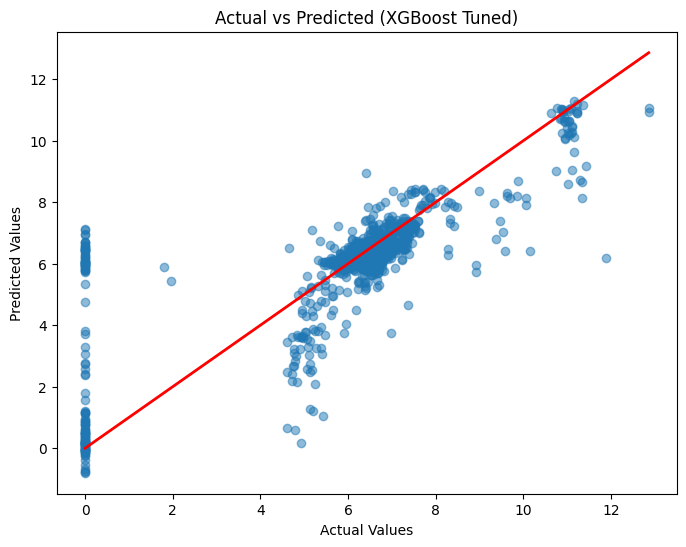

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_test_pred_tuned,alpha=0.5)

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red",linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (XGBoost Tuned)")

plt.show()

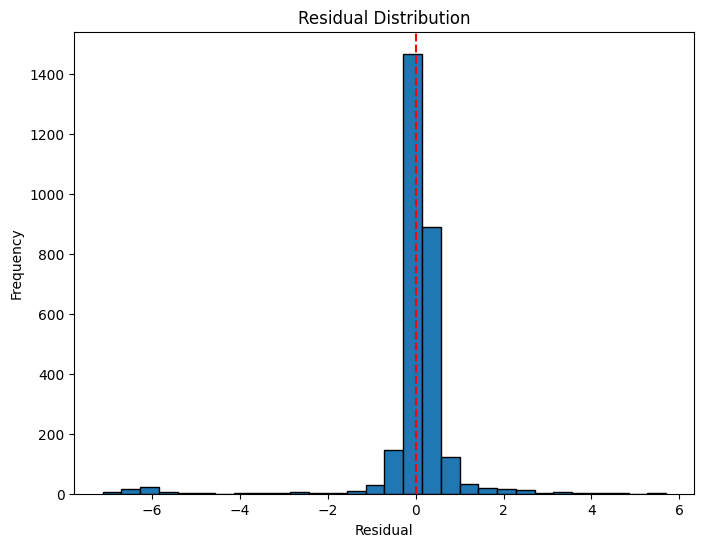

In [63]:
residuals = y_test - y_test_pred_tuned

plt.figure(figsize=(8,6))

plt.hist(residuals,bins=30,edgecolor="black")

plt.axvline(0,color="red",linestyle="--")

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

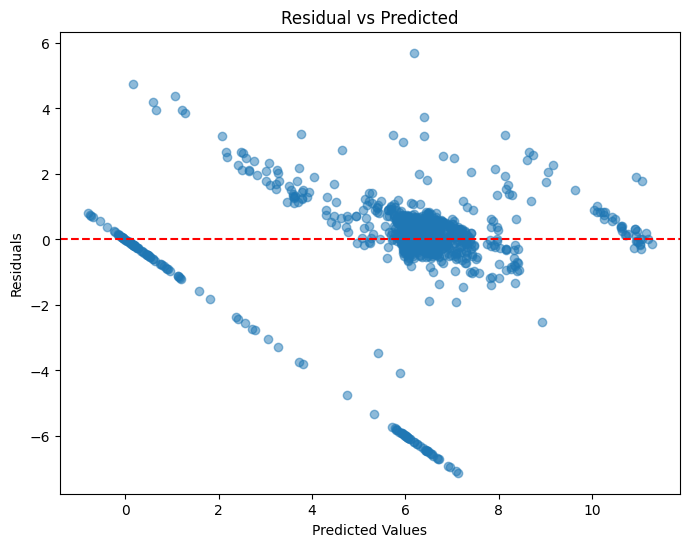

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_pred_tuned, residuals, alpha=0.5)

plt.axhline(0,color="red",linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Predicted")

plt.show()

# 16. Save Final Model

## Objective

Persist the final trained model so that it can be reused for future predictions without retraining.

Model persistence is an important step in deploying machine learning solutions in production environments.

In [65]:
import joblib

In [66]:
joblib.dump(xgb_tuned,"xgboost_quality_model.pkl")

['xgboost_quality_model.pkl']

In [67]:
loaded_model = joblib.load(
    "xgboost_quality_model.pkl"
)

loaded_model


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

# 17. Final Business Recommendations

## Project Summary

This project combined SQL-based manufacturing analytics with machine learning to identify process drivers affecting product quality.

The workflow progressed from identifying quality deviations using SQL, validating process relationships through exploratory data analysis, and finally developing predictive machine learning models capable of forecasting manufacturing quality.

## Key Findings

### SQL Analysis

- Stage 2 Measurement Point 4 exhibited the highest average deviation from its setpoint.
- Stage 1 Measurement Point 1 showed the second highest deviation and was selected for predictive modelling after validating target suitability.

### Exploratory Data Analysis

- The selected quality measurement followed a moderately left-skewed distribution.
- Strong relationships were observed between several manufacturing process variables and the selected quality measurement.
- Correlation analysis indicated that Machine5 temperature-related variables had significant influence on product quality.

### Machine Learning

Four predictive models were evaluated:

- Linear Regression
- Random Forest
- XGBoost
- Tuned XGBoost

Tree-based ensemble models substantially outperformed Linear Regression, confirming the presence of complex non-linear relationships within the manufacturing process.

The tuned XGBoost model achieved the best balance between predictive accuracy and generalization.

### Process Drivers

Feature importance analysis revealed that only a small number of process variables contributed to most of the predictive capability.

Machine5.Temperature3.C.Actual emerged as the most influential manufacturing parameter, followed by Machine2.RawMaterial.Property1 and Machine3.MaterialTemperature.U.Actual.

## Business Recommendations

Based on the analytical findings, the following recommendations are proposed:

- Increase monitoring frequency for Machine5 temperature variables.
- Implement tighter process control on raw material properties.
- Use the trained predictive model as an early warning system to identify quality deviations before final inspection.
- Prioritize process optimization efforts around the highest contributing variables identified by the model rather than treating all parameters equally.

## Conclusion

The project demonstrates how manufacturing process data can be transformed into actionable business insights using SQL, statistical analysis, and machine learning.

The final predictive model provides a practical foundation for proactive quality monitoring and process optimization in industrial manufacturing environments.